# Data Preprocessing

In [135]:
import pandas as pd
import numpy as np
import scipy.stats as st

In [2]:
df = pd.read_csv(r"C:\Users\Adini\Code_files\Web Scraping\Recliners.csv")
df.drop(columns='Unnamed: 0', inplace=True)
df

,Brand,Model,Color,Seater,Rating,Warranty(Months),Cost after Discount(%),Original Cost,Discount(%),EMI,Shipping Days
0,Sleepyhead,Manaual,Brown,1.0,NaN,12,14249,19999,29,685,2.0
1,Casacraft from Pepperfry,Norton,Brown,1.0,NaN,36,40999,50999,20,1969,3.0
2,Royaloak,Nelson,NaN,1.0,NaN,12,13990,30000,53,672,2.0
3,Sleepyhead,Manaual,Black,1.0,NaN,36,14249,19999,29,685,2.0
4,Duroflex,Avalon,Green,1.0,NaN,12,18049,25399,29,867,NaN
...,...,...,...,...,...,...,...,...,...,...,...
162,Casacraft from Pepperfry,Larenzo,Pink,3.0,5.0,36,59999,79999,25,2881,NaN
163,Woodsworth from Pepperfry,Serena,Blue,NaN,NaN,36,55999,72999,23,2689,NaN
164,Woodsworth from Pepperfry,Serena,Blue,NaN,NaN,36,64999,84999,24,3121,NaN
165,Woodsworth from Pepperfry,Serena,Blue,NaN,NaN,36,64999,84999,24,3121,NaN


### Data description

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Brand                   167 non-null    str    
 1   Model                   167 non-null    str    
 2   Color                   158 non-null    str    
 3   Seater                  152 non-null    float64
 4   Rating                  75 non-null     float64
 5   Warranty(Months)        167 non-null    int64  
 6   Cost after Discount(%)  167 non-null    int64  
 7   Original Cost           167 non-null    int64  
 8   Discount(%)             167 non-null    int64  
 9   EMI                     167 non-null    int64  
 10  Shipping Days           98 non-null     float64
dtypes: float64(3), int64(5), str(3)
memory usage: 14.5 KB


In [4]:
df.describe()

,Seater,Rating,Warranty(Months),Cost after Discount(%),Original Cost,Discount(%),EMI,Shipping Days
count,152.000000,75.000000,167.000000,167.000000,167.000000,167.000000,167.000000,98.000000
mean,1.585526,4.533333,30.826347,68003.688623,101732.257485,31.790419,3265.473054,2.622449
std,0.784317,0.659306,13.333978,54257.916402,79924.337881,15.710035,2605.090968,0.739397
min,1.000000,1.000000,12.000000,13990.000000,19999.000000,5.000000,672.000000,2.000000
25%,1.000000,4.500000,20.000000,30440.000000,47690.000000,21.000000,1462.000000,2.000000
50%,1.000000,4.500000,36.000000,51999.000000,74999.000000,28.000000,2497.000000,2.000000
75%,2.000000,5.000000,36.000000,79999.000000,126150.000000,40.000000,3841.000000,3.000000
max,3.000000,5.000000,60.000000,268920.000000,448200.000000,76.000000,12912.000000,4.000000


### Filling missing values

In [5]:
df.isnull().sum()

Brand                      0
Model                      0
Color                      9
Seater                    15
Rating                    92
Warranty(Months)           0
Cost after Discount(%)     0
Original Cost              0
Discount(%)                0
EMI                        0
Shipping Days             69
dtype: int64

In [6]:
# Many recliners had missing ratings because several products were newly listed or had insufficient customer reviews.

In [7]:
df['Seater'].skew()

np.float64(0.8807512564430271)

In [8]:
df['Rating'].skew()

np.float64(-2.996027999474602)

In [9]:
df['Shipping Days'].skew()

np.float64(0.7378057598754469)

In [10]:
df['Color'].value_counts()

Color
Brown        43
Beige        34
Grey         28
Blue         14
Green        10
Mocca         4
Black         3
Red           3
Charcoal      3
Orange        2
Tan           2
Cream         2
Pink          2
Cocoa         1
Gold          1
Chestnut      1
Persimmon     1
Coffee        1
Olive         1
Granite       1
Teak          1
Name: count, dtype: int64

In [11]:
df.fillna({
    'Seater':df['Seater'].median(),
    'Rating':df['Rating'].median(),
    'Shipping Days':df['Shipping Days'].median(),
    'Color':df['Color'].mode()[0]
}, inplace=True)

,Brand,Model,Color,Seater,Rating,Warranty(Months),Cost after Discount(%),Original Cost,Discount(%),EMI,Shipping Days
0,Sleepyhead,Manaual,Brown,1.0,4.5,12,14249,19999,29,685,2.0
1,Casacraft from Pepperfry,Norton,Brown,1.0,4.5,36,40999,50999,20,1969,3.0
2,Royaloak,Nelson,Brown,1.0,4.5,12,13990,30000,53,672,2.0
3,Sleepyhead,Manaual,Black,1.0,4.5,36,14249,19999,29,685,2.0
4,Duroflex,Avalon,Green,1.0,4.5,12,18049,25399,29,867,2.0
...,...,...,...,...,...,...,...,...,...,...,...
162,Casacraft from Pepperfry,Larenzo,Pink,3.0,5.0,36,59999,79999,25,2881,2.0
163,Woodsworth from Pepperfry,Serena,Blue,1.0,4.5,36,55999,72999,23,2689,2.0
164,Woodsworth from Pepperfry,Serena,Blue,1.0,4.5,36,64999,84999,24,3121,2.0
165,Woodsworth from Pepperfry,Serena,Blue,1.0,4.5,36,64999,84999,24,3121,2.0


In [12]:
df.isnull().sum()

Brand                     0
Model                     0
Color                     0
Seater                    0
Rating                    0
Warranty(Months)          0
Cost after Discount(%)    0
Original Cost             0
Discount(%)               0
EMI                       0
Shipping Days             0
dtype: int64

### Removing Duplicate values

In [13]:
df.duplicated().sum()

np.int64(7)

In [14]:
df.drop_duplicates(keep='first', inplace=True)

In [15]:
df.duplicated().sum()

np.int64(0)

### Changing datatypes

In [16]:
df['Seater'] = df['Seater'].astype(int)
df['Shipping Days'] = df['Shipping Days'].astype(int)

In [17]:
df

,Brand,Model,Color,Seater,Rating,Warranty(Months),Cost after Discount(%),Original Cost,Discount(%),EMI,Shipping Days
0,Sleepyhead,Manaual,Brown,1,4.5,12,14249,19999,29,685,2
1,Casacraft from Pepperfry,Norton,Brown,1,4.5,36,40999,50999,20,1969,3
2,Royaloak,Nelson,Brown,1,4.5,12,13990,30000,53,672,2
3,Sleepyhead,Manaual,Black,1,4.5,36,14249,19999,29,685,2
4,Duroflex,Avalon,Green,1,4.5,12,18049,25399,29,867,2
...,...,...,...,...,...,...,...,...,...,...,...
161,Casacraft from Pepperfry,Nelida,Brown,3,4.5,36,57999,68999,16,2785,2
162,Casacraft from Pepperfry,Larenzo,Pink,3,5.0,36,59999,79999,25,2881,2
163,Woodsworth from Pepperfry,Serena,Blue,1,4.5,36,55999,72999,23,2689,2
164,Woodsworth from Pepperfry,Serena,Blue,1,4.5,36,64999,84999,24,3121,2


### Handling Outliers

#### Using z-score method

In [18]:
def z_score(column):
    mean = df[column].mean()
    std = df[column].std()
    
    x = (df[column] - mean)/std
    return df[(x<-3) | (x>3)]

In [19]:
z_score('Seater')

,Brand,Model,Color,Seater,Rating,Warranty(Months),Cost after Discount(%),Original Cost,Discount(%),EMI,Shipping Days


In [20]:
z_score('Rating')

,Brand,Model,Color,Seater,Rating,Warranty(Months),Cost after Discount(%),Original Cost,Discount(%),EMI,Shipping Days
139,Duroflex,Avalon,Orange,1,2.0,36,23939,33599,29,1150,2
141,Nilkamal,Matt,Blue,2,1.0,36,30890,90900,66,1484,2


In [21]:
# In general, rating lies between 1 and 5. So the above are considered not as outliers

In [22]:
z_score('Warranty(Months)')

,Brand,Model,Color,Seater,Rating,Warranty(Months),Cost after Discount(%),Original Cost,Discount(%),EMI,Shipping Days


In [23]:
z_score('Cost after Discount(%)')

,Brand,Model,Color,Seater,Rating,Warranty(Months),Cost after Discount(%),Original Cost,Discount(%),EMI,Shipping Days
38,LA-Z-BOY,Cardinal,Mocca,1,5.0,12,242250,255000,5,11632,2
79,Durian,Splendor,Green,3,4.5,60,268920,448200,40,12912,3
80,Durian,Splendor,Green,2,4.5,60,239280,398800,40,11489,3


In [24]:
z_score('Original Cost')

,Brand,Model,Color,Seater,Rating,Warranty(Months),Cost after Discount(%),Original Cost,Discount(%),EMI,Shipping Days
46,Casacraft from Pepperfry,Loures,Brown,1,4.5,36,224999,349999,36,10803,2
79,Durian,Splendor,Green,3,4.5,60,268920,448200,40,12912,3
80,Durian,Splendor,Green,2,4.5,60,239280,398800,40,11489,3
94,Casacraft from Pepperfry,Riyadh,Green,2,4.5,36,209999,354999,41,10083,2


In [25]:
# In general, maybe due to features and quality or brand the cost maybe higher and that won't be treated as an outlier in case of recliners cost.

In [26]:
z_score('Discount(%)')

,Brand,Model,Color,Seater,Rating,Warranty(Months),Cost after Discount(%),Original Cost,Discount(%),EMI,Shipping Days


In [27]:
z_score('EMI')

,Brand,Model,Color,Seater,Rating,Warranty(Months),Cost after Discount(%),Original Cost,Discount(%),EMI,Shipping Days
38,LA-Z-BOY,Cardinal,Mocca,1,5.0,12,242250,255000,5,11632,2
79,Durian,Splendor,Green,3,4.5,60,268920,448200,40,12912,3
80,Durian,Splendor,Green,2,4.5,60,239280,398800,40,11489,3


In [28]:
# Due to more cost of the recliners, EMI column also contain higher values.

In [29]:
z_score('Shipping Days')

,Brand,Model,Color,Seater,Rating,Warranty(Months),Cost after Discount(%),Original Cost,Discount(%),EMI,Shipping Days


#### Using IQR method

In [30]:
def iqr_method(column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    
    iqr = q3 - q1
    
    lb = q1 - 1.5*iqr
    ub = q3 + 1.5*iqr
    return df[(df[column]>ub) | (df[column]<lb)]

In [31]:
for num_col in df.select_dtypes(include=[np.number]).columns:
    outliers = iqr_method(num_col)

    print(f"\nColumn: {num_col}")
    print(f"Number of outliers: {len(outliers)}")

    print(outliers[[num_col]])


Column: Seater
Number of outliers: 0
Empty DataFrame
Columns: [Seater]
Index: []

Column: Rating
Number of outliers: 48
     Rating
11      5.0
14      5.0
15      5.0
17      5.0
18      4.0
19      5.0
20      4.0
21      5.0
22      4.0
24      5.0
38      5.0
39      5.0
40      5.0
43      5.0
44      5.0
45      5.0
47      5.0
59      5.0
61      4.0
63      5.0
64      5.0
65      5.0
66      4.0
68      5.0
82      4.0
84      5.0
85      4.0
86      4.0
89      4.0
104     5.0
105     5.0
106     4.0
107     5.0
108     5.0
109     3.5
110     5.0
112     5.0
113     5.0
115     5.0
118     3.5
119     3.5
121     5.0
122     5.0
137     5.0
138     5.0
139     2.0
141     1.0
162     5.0

Column: Warranty(Months)
Number of outliers: 0
Empty DataFrame
Columns: [Warranty(Months)]
Index: []

Column: Cost after Discount(%)
Number of outliers: 17
     Cost after Discount(%)
19                   198360
38                   242250
42                   199999
46                   2

### Create Feature Engineering Columns

In [32]:
df['Discount Amount'] = (
    df['Original Cost'] -
    df['Cost after Discount(%)']
)

In [33]:
df['Warranty(Years)'] = (
    df['Warranty(Months)'] / 12
).astype(int)

In [34]:
df

,Brand,Model,Color,Seater,Rating,Warranty(Months),Cost after Discount(%),Original Cost,Discount(%),EMI,Shipping Days,Discount Amount,Warranty(Years)
0,Sleepyhead,Manaual,Brown,1,4.5,12,14249,19999,29,685,2,5750,1
1,Casacraft from Pepperfry,Norton,Brown,1,4.5,36,40999,50999,20,1969,3,10000,3
2,Royaloak,Nelson,Brown,1,4.5,12,13990,30000,53,672,2,16010,1
3,Sleepyhead,Manaual,Black,1,4.5,36,14249,19999,29,685,2,5750,3
4,Duroflex,Avalon,Green,1,4.5,12,18049,25399,29,867,2,7350,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
161,Casacraft from Pepperfry,Nelida,Brown,3,4.5,36,57999,68999,16,2785,2,11000,3
162,Casacraft from Pepperfry,Larenzo,Pink,3,5.0,36,59999,79999,25,2881,2,20000,3
163,Woodsworth from Pepperfry,Serena,Blue,1,4.5,36,55999,72999,23,2689,2,17000,3
164,Woodsworth from Pepperfry,Serena,Blue,1,4.5,36,64999,84999,24,3121,2,20000,3


In [35]:
df['Cost after Discount(%)'].max()

np.int64(268920)

In [36]:
df['Price Category'] = pd.cut(
    df['Cost after Discount(%)'],
    bins=[0,30000,70000,150000,300000],
    labels=['Budget','Mid-Range','Premium','Luxury']
)

In [37]:
df

,Brand,Model,Color,Seater,Rating,Warranty(Months),Cost after Discount(%),Original Cost,Discount(%),EMI,Shipping Days,Discount Amount,Warranty(Years),Price Category
0,Sleepyhead,Manaual,Brown,1,4.5,12,14249,19999,29,685,2,5750,1,Budget
1,Casacraft from Pepperfry,Norton,Brown,1,4.5,36,40999,50999,20,1969,3,10000,3,Mid-Range
2,Royaloak,Nelson,Brown,1,4.5,12,13990,30000,53,672,2,16010,1,Budget
3,Sleepyhead,Manaual,Black,1,4.5,36,14249,19999,29,685,2,5750,3,Budget
4,Duroflex,Avalon,Green,1,4.5,12,18049,25399,29,867,2,7350,1,Budget
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161,Casacraft from Pepperfry,Nelida,Brown,3,4.5,36,57999,68999,16,2785,2,11000,3,Mid-Range
162,Casacraft from Pepperfry,Larenzo,Pink,3,5.0,36,59999,79999,25,2881,2,20000,3,Mid-Range
163,Woodsworth from Pepperfry,Serena,Blue,1,4.5,36,55999,72999,23,2689,2,17000,3,Mid-Range
164,Woodsworth from Pepperfry,Serena,Blue,1,4.5,36,64999,84999,24,3121,2,20000,3,Mid-Range


### Arranging column names

In [38]:
df = df[['Brand', 'Model', 'Color', 'Seater', 'Rating', 'Warranty(Months)', 'Warranty(Years)', 'Original Cost', 'Discount(%)', 'Discount Amount', 'Cost after Discount(%)', 'EMI', 'Shipping Days', 'Price Category']]

In [39]:
df

,Brand,Model,Color,Seater,Rating,Warranty(Months),Warranty(Years),Original Cost,Discount(%),Discount Amount,Cost after Discount(%),EMI,Shipping Days,Price Category
0,Sleepyhead,Manaual,Brown,1,4.5,12,1,19999,29,5750,14249,685,2,Budget
1,Casacraft from Pepperfry,Norton,Brown,1,4.5,36,3,50999,20,10000,40999,1969,3,Mid-Range
2,Royaloak,Nelson,Brown,1,4.5,12,1,30000,53,16010,13990,672,2,Budget
3,Sleepyhead,Manaual,Black,1,4.5,36,3,19999,29,5750,14249,685,2,Budget
4,Duroflex,Avalon,Green,1,4.5,12,1,25399,29,7350,18049,867,2,Budget
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161,Casacraft from Pepperfry,Nelida,Brown,3,4.5,36,3,68999,16,11000,57999,2785,2,Mid-Range
162,Casacraft from Pepperfry,Larenzo,Pink,3,5.0,36,3,79999,25,20000,59999,2881,2,Mid-Range
163,Woodsworth from Pepperfry,Serena,Blue,1,4.5,36,3,72999,23,17000,55999,2689,2,Mid-Range
164,Woodsworth from Pepperfry,Serena,Blue,1,4.5,36,3,84999,24,20000,64999,3121,2,Mid-Range


### Rename columns

In [40]:
df.rename(columns={
    'Cost after Discount(%)':'Final Price'
}, inplace=True)

In [41]:
df

,Brand,Model,Color,Seater,Rating,Warranty(Months),Warranty(Years),Original Cost,Discount(%),Discount Amount,Final Price,EMI,Shipping Days,Price Category
0,Sleepyhead,Manaual,Brown,1,4.5,12,1,19999,29,5750,14249,685,2,Budget
1,Casacraft from Pepperfry,Norton,Brown,1,4.5,36,3,50999,20,10000,40999,1969,3,Mid-Range
2,Royaloak,Nelson,Brown,1,4.5,12,1,30000,53,16010,13990,672,2,Budget
3,Sleepyhead,Manaual,Black,1,4.5,36,3,19999,29,5750,14249,685,2,Budget
4,Duroflex,Avalon,Green,1,4.5,12,1,25399,29,7350,18049,867,2,Budget
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161,Casacraft from Pepperfry,Nelida,Brown,3,4.5,36,3,68999,16,11000,57999,2785,2,Mid-Range
162,Casacraft from Pepperfry,Larenzo,Pink,3,5.0,36,3,79999,25,20000,59999,2881,2,Mid-Range
163,Woodsworth from Pepperfry,Serena,Blue,1,4.5,36,3,72999,23,17000,55999,2689,2,Mid-Range
164,Woodsworth from Pepperfry,Serena,Blue,1,4.5,36,3,84999,24,20000,64999,3121,2,Mid-Range


In [42]:
# Saving the preprocessed/cleaned data
df.to_csv(r'Recliners_cleaned.csv', index=False)

### Loading cleaned data

In [2]:
df = pd.read_csv(r"C:\Users\Adini\Code_files\Web Scraping\Recliners_cleaned.csv")
df

,Brand,Model,Color,Seater,Rating,Warranty(Months),Warranty(Years),Original Cost,Discount(%),Discount Amount,Final Price,EMI,Shipping Days,Price Category
0,Sleepyhead,Manaual,Brown,1,4.5,12,1,19999,29,5750,14249,685,2,Budget
1,Casacraft from Pepperfry,Norton,Brown,1,4.5,36,3,50999,20,10000,40999,1969,3,Mid-Range
2,Royaloak,Nelson,Brown,1,4.5,12,1,30000,53,16010,13990,672,2,Budget
3,Sleepyhead,Manaual,Black,1,4.5,36,3,19999,29,5750,14249,685,2,Budget
4,Duroflex,Avalon,Green,1,4.5,12,1,25399,29,7350,18049,867,2,Budget
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,Casacraft from Pepperfry,Nelida,Brown,3,4.5,36,3,68999,16,11000,57999,2785,2,Mid-Range
156,Casacraft from Pepperfry,Larenzo,Pink,3,5.0,36,3,79999,25,20000,59999,2881,2,Mid-Range
157,Woodsworth from Pepperfry,Serena,Blue,1,4.5,36,3,72999,23,17000,55999,2689,2,Mid-Range
158,Woodsworth from Pepperfry,Serena,Blue,1,4.5,36,3,84999,24,20000,64999,3121,2,Mid-Range


# Data Analysis using Visualization

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

### Univariate Analysis

##### Numerical columns

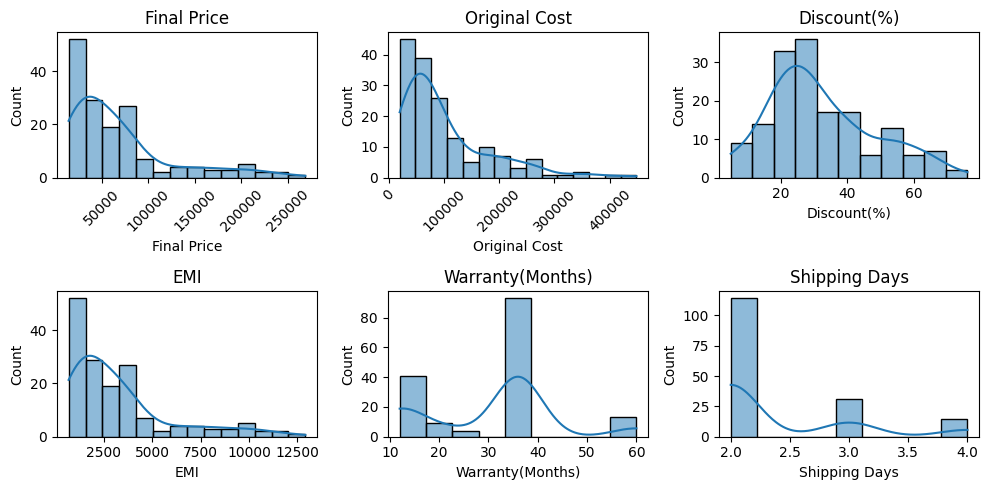

In [21]:
# Histogram
plt.figure(figsize=(10,5))

plt.subplot(2,3,1)
sns.histplot(df['Final Price'], kde=True)
plt.title('Final Price')
plt.xticks(rotation=45)

plt.subplot(2,3,2)
sns.histplot(df['Original Cost'], kde=True)
plt.title('Original Cost')
plt.xticks(rotation=45)

plt.subplot(2,3,3)
sns.histplot(df['Discount(%)'], kde=True)
plt.title('Discount(%)')

plt.subplot(2,3,4)
sns.histplot(df['EMI'], kde=True)
plt.title('EMI')

plt.subplot(2,3,5)
sns.histplot(df['Warranty(Months)'], kde=True)
plt.title('Warranty(Months)')

plt.subplot(2,3,6)
sns.histplot(df['Shipping Days'], kde=True)
plt.title('Shipping Days')

plt.tight_layout()
plt.show()

**Interpretation**
- Final Price, Original Cost, and EMI are positively skewed (right-skewed).
- Majority of recliners belong to budget and mid-range categories.
- Very few luxury recliners with extremely high prices pull the distribution toward the right.
- EMI distribution follows price distribution because EMI directly depends on product cost.
- Most recliners receive discounts in the 20–30% range.
- Extremely high discounts (>60%) are rare.
- Majority of recliners offer medium-to-long-term warranties, mainly around 36 months.

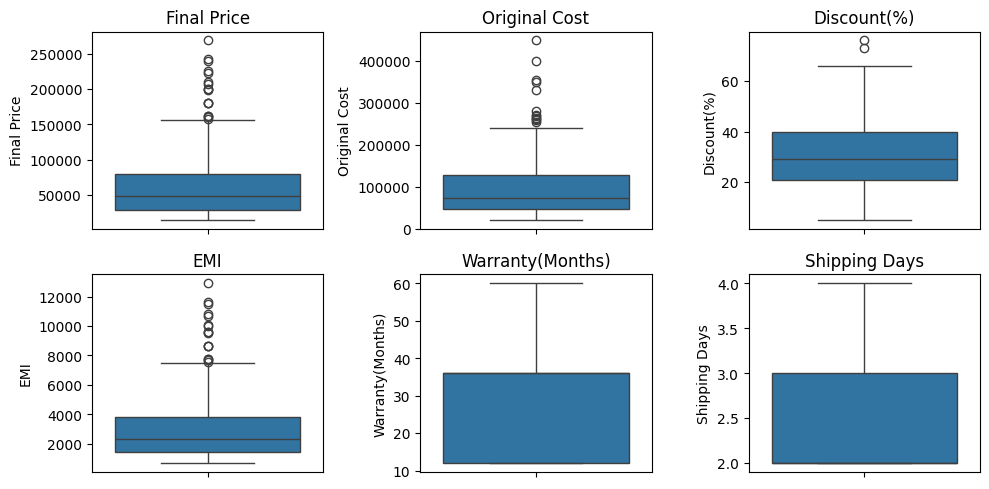

In [23]:
# Boxplot
plt.figure(figsize=(10,5))

plt.subplot(2,3,1)
sns.boxplot(df['Final Price'])
plt.title('Final Price')
plt.xticks(rotation=45)

plt.subplot(2,3,2)
sns.boxplot(df['Original Cost'])
plt.title('Original Cost')
plt.xticks(rotation=45)

plt.subplot(2,3,3)
sns.boxplot(df['Discount(%)'])
plt.title('Discount(%)')

plt.subplot(2,3,4)
sns.boxplot(df['EMI'])
plt.title('EMI')

plt.subplot(2,3,5)
sns.boxplot(df['Warranty(Months)'])
plt.title('Warranty(Months)')

plt.subplot(2,3,6)
sns.boxplot(df['Shipping Days'])
plt.title('Shipping Days')

plt.tight_layout()
plt.show()

**Interpretation**
- Several premium recliners appear as upper-end outliers in Final Price, Original Cost, and EMI. These outliers likely represent luxury recliner segments with premium materials and branding.
- A small number of recliners offer exceptionally high discounts (>60%), possibly due to clearance sales or aggressive promotional pricing.

##### Categorical columns

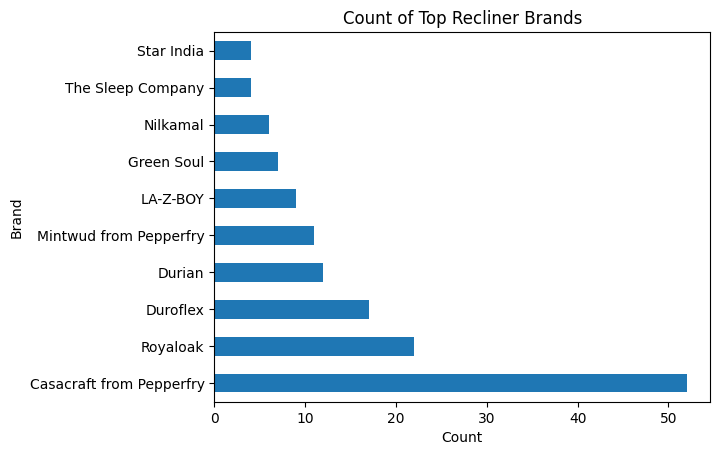

In [163]:
# Top 10 Brands
df['Brand'].value_counts().head(10).plot(kind='barh')
plt.title("Count of Top Recliner Brands")
plt.xlabel('Count')
plt.show()

**Interpretation**
- Casacraft from Pepperfry dominates the dataset with the highest number of recliner listings.

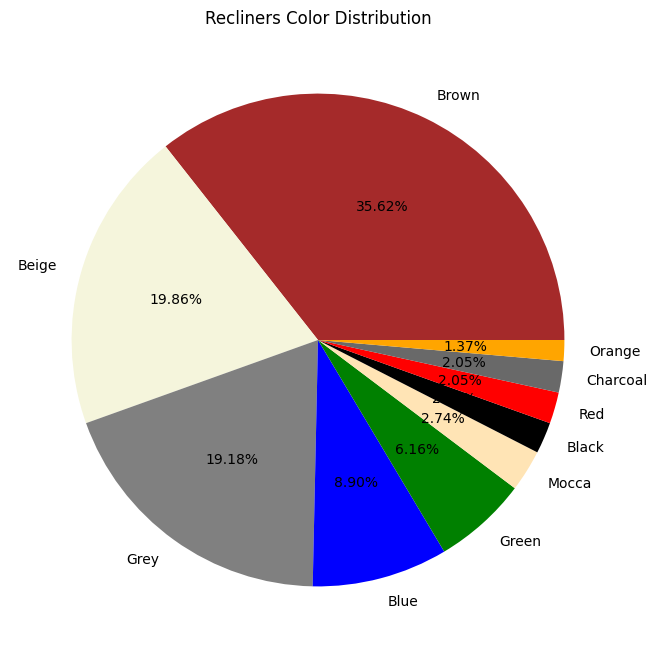

In [160]:
# Color Distribution
color_counts = df['Color'].value_counts().head(10)

plt.figure(figsize=(8,8))

plt.pie(
    color_counts,
    labels=color_counts.index,   # show color names
    autopct='%.2f%%',
    colors=[
        'brown', 'beige', 'grey', 'blue', 'green',
        'moccasin', 'black', 'red', 'dimgray', 'orange'
    ]
)

plt.title("Recliners Color Distribution")
plt.show()

**Interpretation**
- Neutral colors such as Brown, Beige, and Grey dominate the recliner market. These colors are likely preferred because they match most interior designs.

### Bivariate Analysis

##### Numerical vs Numerical

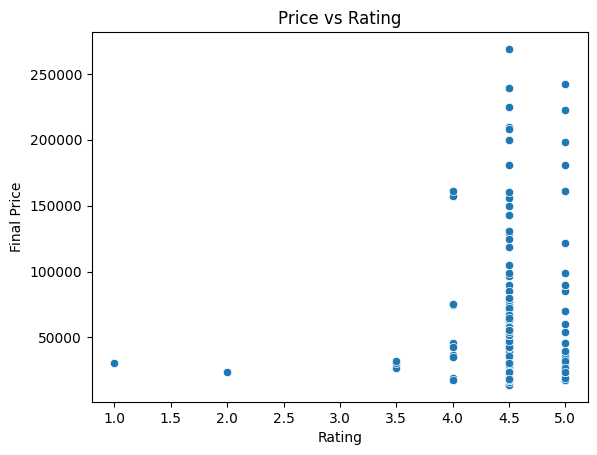

In [164]:
# Price vs Rating
sns.scatterplot(y = df['Final Price'], x = df['Rating'])
plt.title('Price vs Rating')
plt.show()

**Interpretation**
- Most recliners have ratings clustered around 4.5–5.0.
- No strong relationship is observed between rating and price.

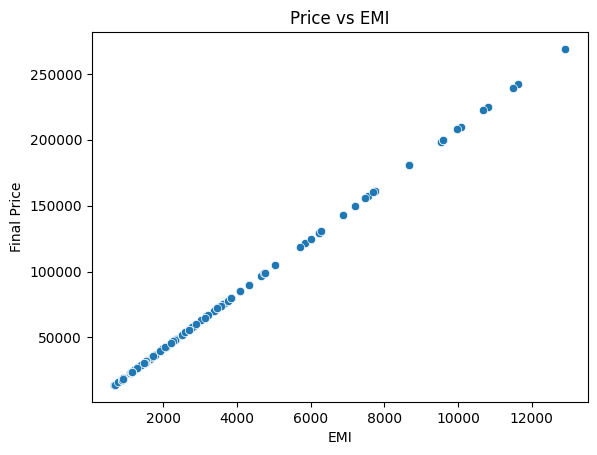

In [165]:
# Price vs EMI
sns.scatterplot(y = df['Final Price'], x = df['EMI'])
plt.title('Price vs EMI')
plt.show()

**Interpretation**
- Final Price and EMI show a strong positive relationship.
- Higher-priced recliners naturally result in higher monthly EMI values.

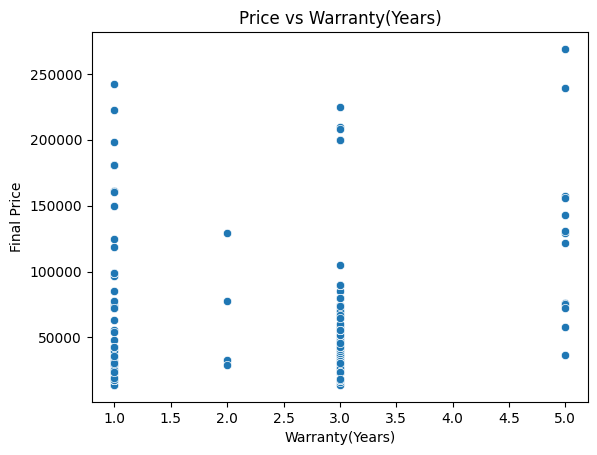

In [166]:
# Price vs Warranty(Years)
sns.scatterplot(y = df['Final Price'], x = df['Warranty(Years)'])
plt.title('Price vs Warranty(Years)')
plt.show()

**Interpretation**
- Recliners with 3-year and 1-year warranties appear more frequently in mid-range and premium price categories.

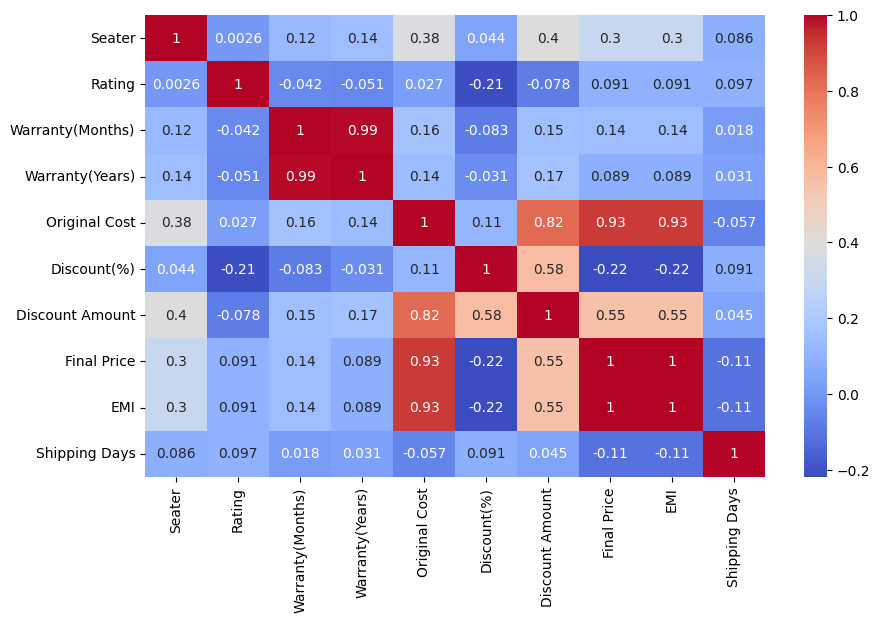

In [82]:
# Correlation Heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

**Interpretation**
+ Strong positive correlation exists between:
    - Final Price and EMI
    - Final Price and Original Cost
    - Original Cost and EMI
+ Weak correlation exists between:
    - Rating and Discount(%)
    - Rating and Warranty
    - Warranty and Discount(%)

##### Categorical vs Numerical

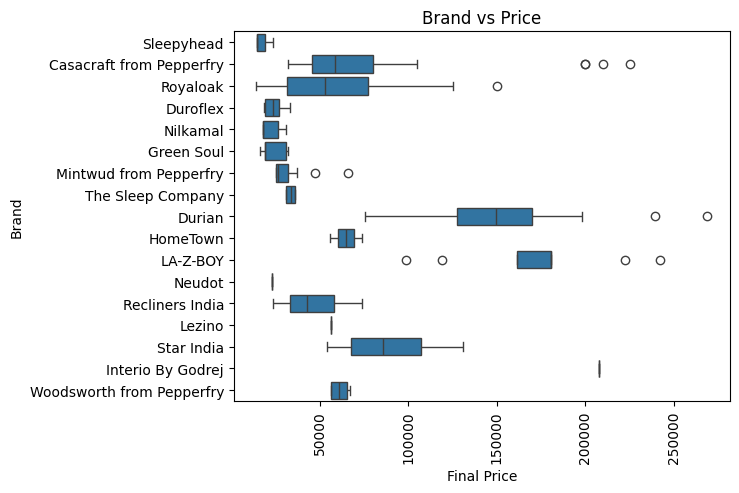

In [172]:
# Brand vs price
sns.boxplot(data=df, y='Brand', x='Final Price')
plt.xticks(rotation=90)
plt.title('Brand vs Price')
plt.show()

**Interpretation**
- Durian, LA-Z-BOY, and Casacraft from Pepperfry contain several premium-priced recliners.
- Sleepyhead mainly targets the budget recliner segment.

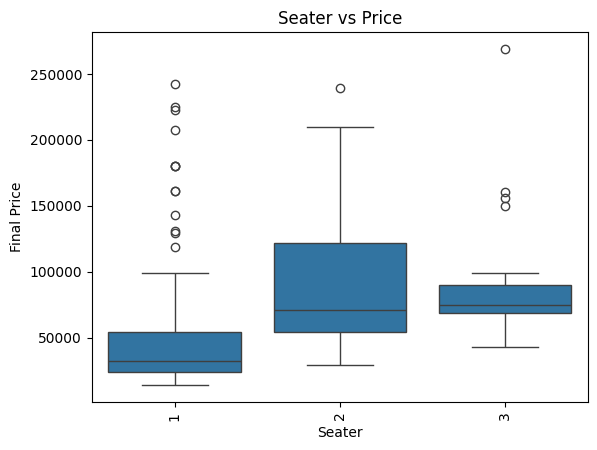

In [173]:
# Seater vs price
sns.boxplot(data=df, x='Seater', y='Final Price')
plt.xticks(rotation=90)
plt.title('Seater vs Price')
plt.show()

**Interpretation**
- Although 3-seater recliners generally cost more, several premium luxury recliners are also present in the 1-seater category.
- This suggests that pricing depends not only on seating capacity but also on brand, material quality, and premium features.

##### Categorical vs Categorical

In [112]:
top_5_brands = df[df['Brand'].isin(df['Brand'].value_counts().head(5).index.tolist())][['Brand', 'Color']]

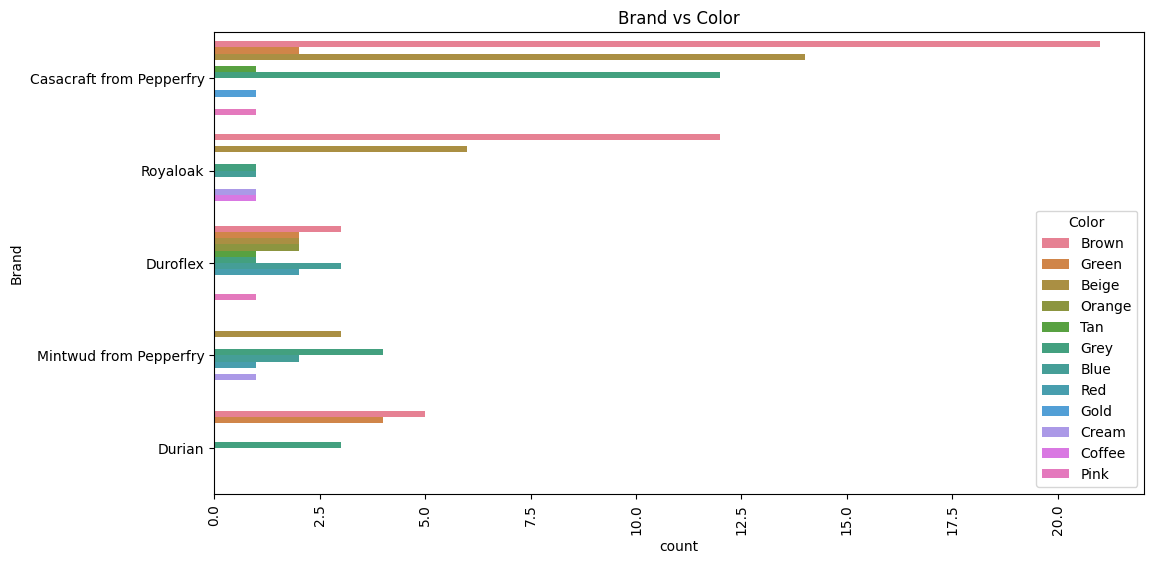

In [183]:
# Brand vs Color
plt.figure(figsize=(12,6))
sns.countplot(data=top_5_brands, y='Brand', hue='Color')
plt.xticks(rotation=90)
plt.title('Brand vs Color')
plt.show()

**Interpretation**
- Brown and Beige recliners dominate across most brands.
- Some brands focus more on neutral color themes.
- Bright colors are comparatively rare in the recliner market.

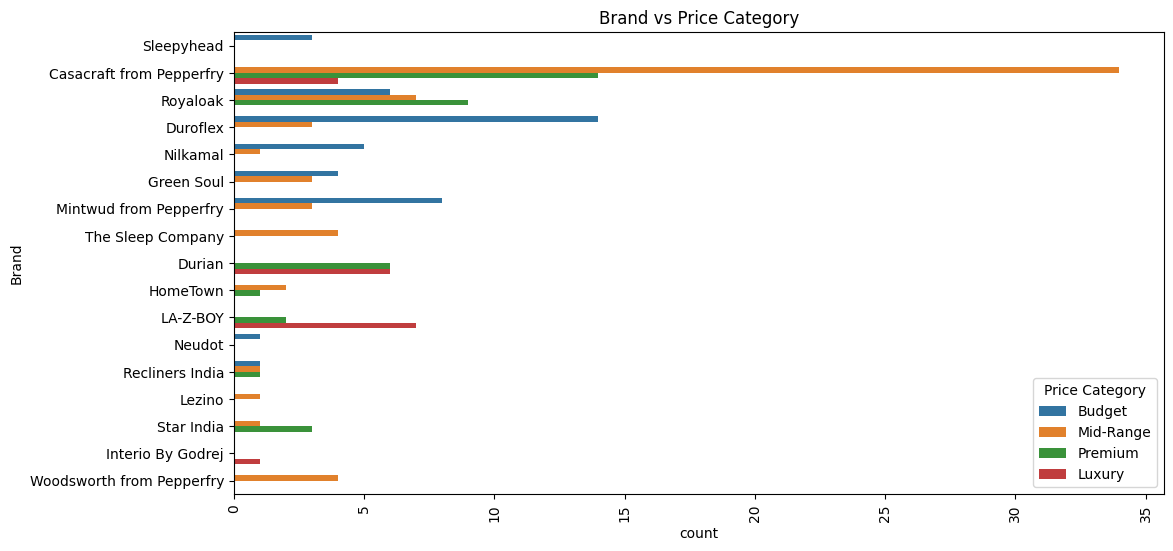

In [178]:
# Brand vs Price Category
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y='Brand',
    hue='Price Category'
)

plt.xticks(rotation=90)
plt.title('Brand vs Price Category')
plt.show()

**Interpretation**
- Some brands mainly focus on Budget and Mid-range recliners.
- Premium brands have more Luxury-category recliners.
- Brand positioning strongly influences pricing category.

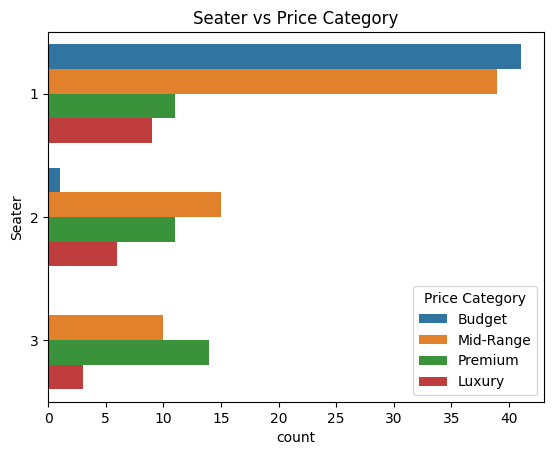

In [179]:
# Seater vs Price Category
sns.countplot(
    data=df,
    y='Seater',
    hue='Price Category'
)
plt.title('Seater vs Price Category')
plt.show()

**Interpretation**
- 1-seater recliners dominate the Budget and Mid-range segments.
- 2-seater recliners dominate the Mid-range segments.
- 3-seater recliners are more common in Premium and Mid-range categories.

### Multivariate Analysis

<Figure size 500x500 with 0 Axes>

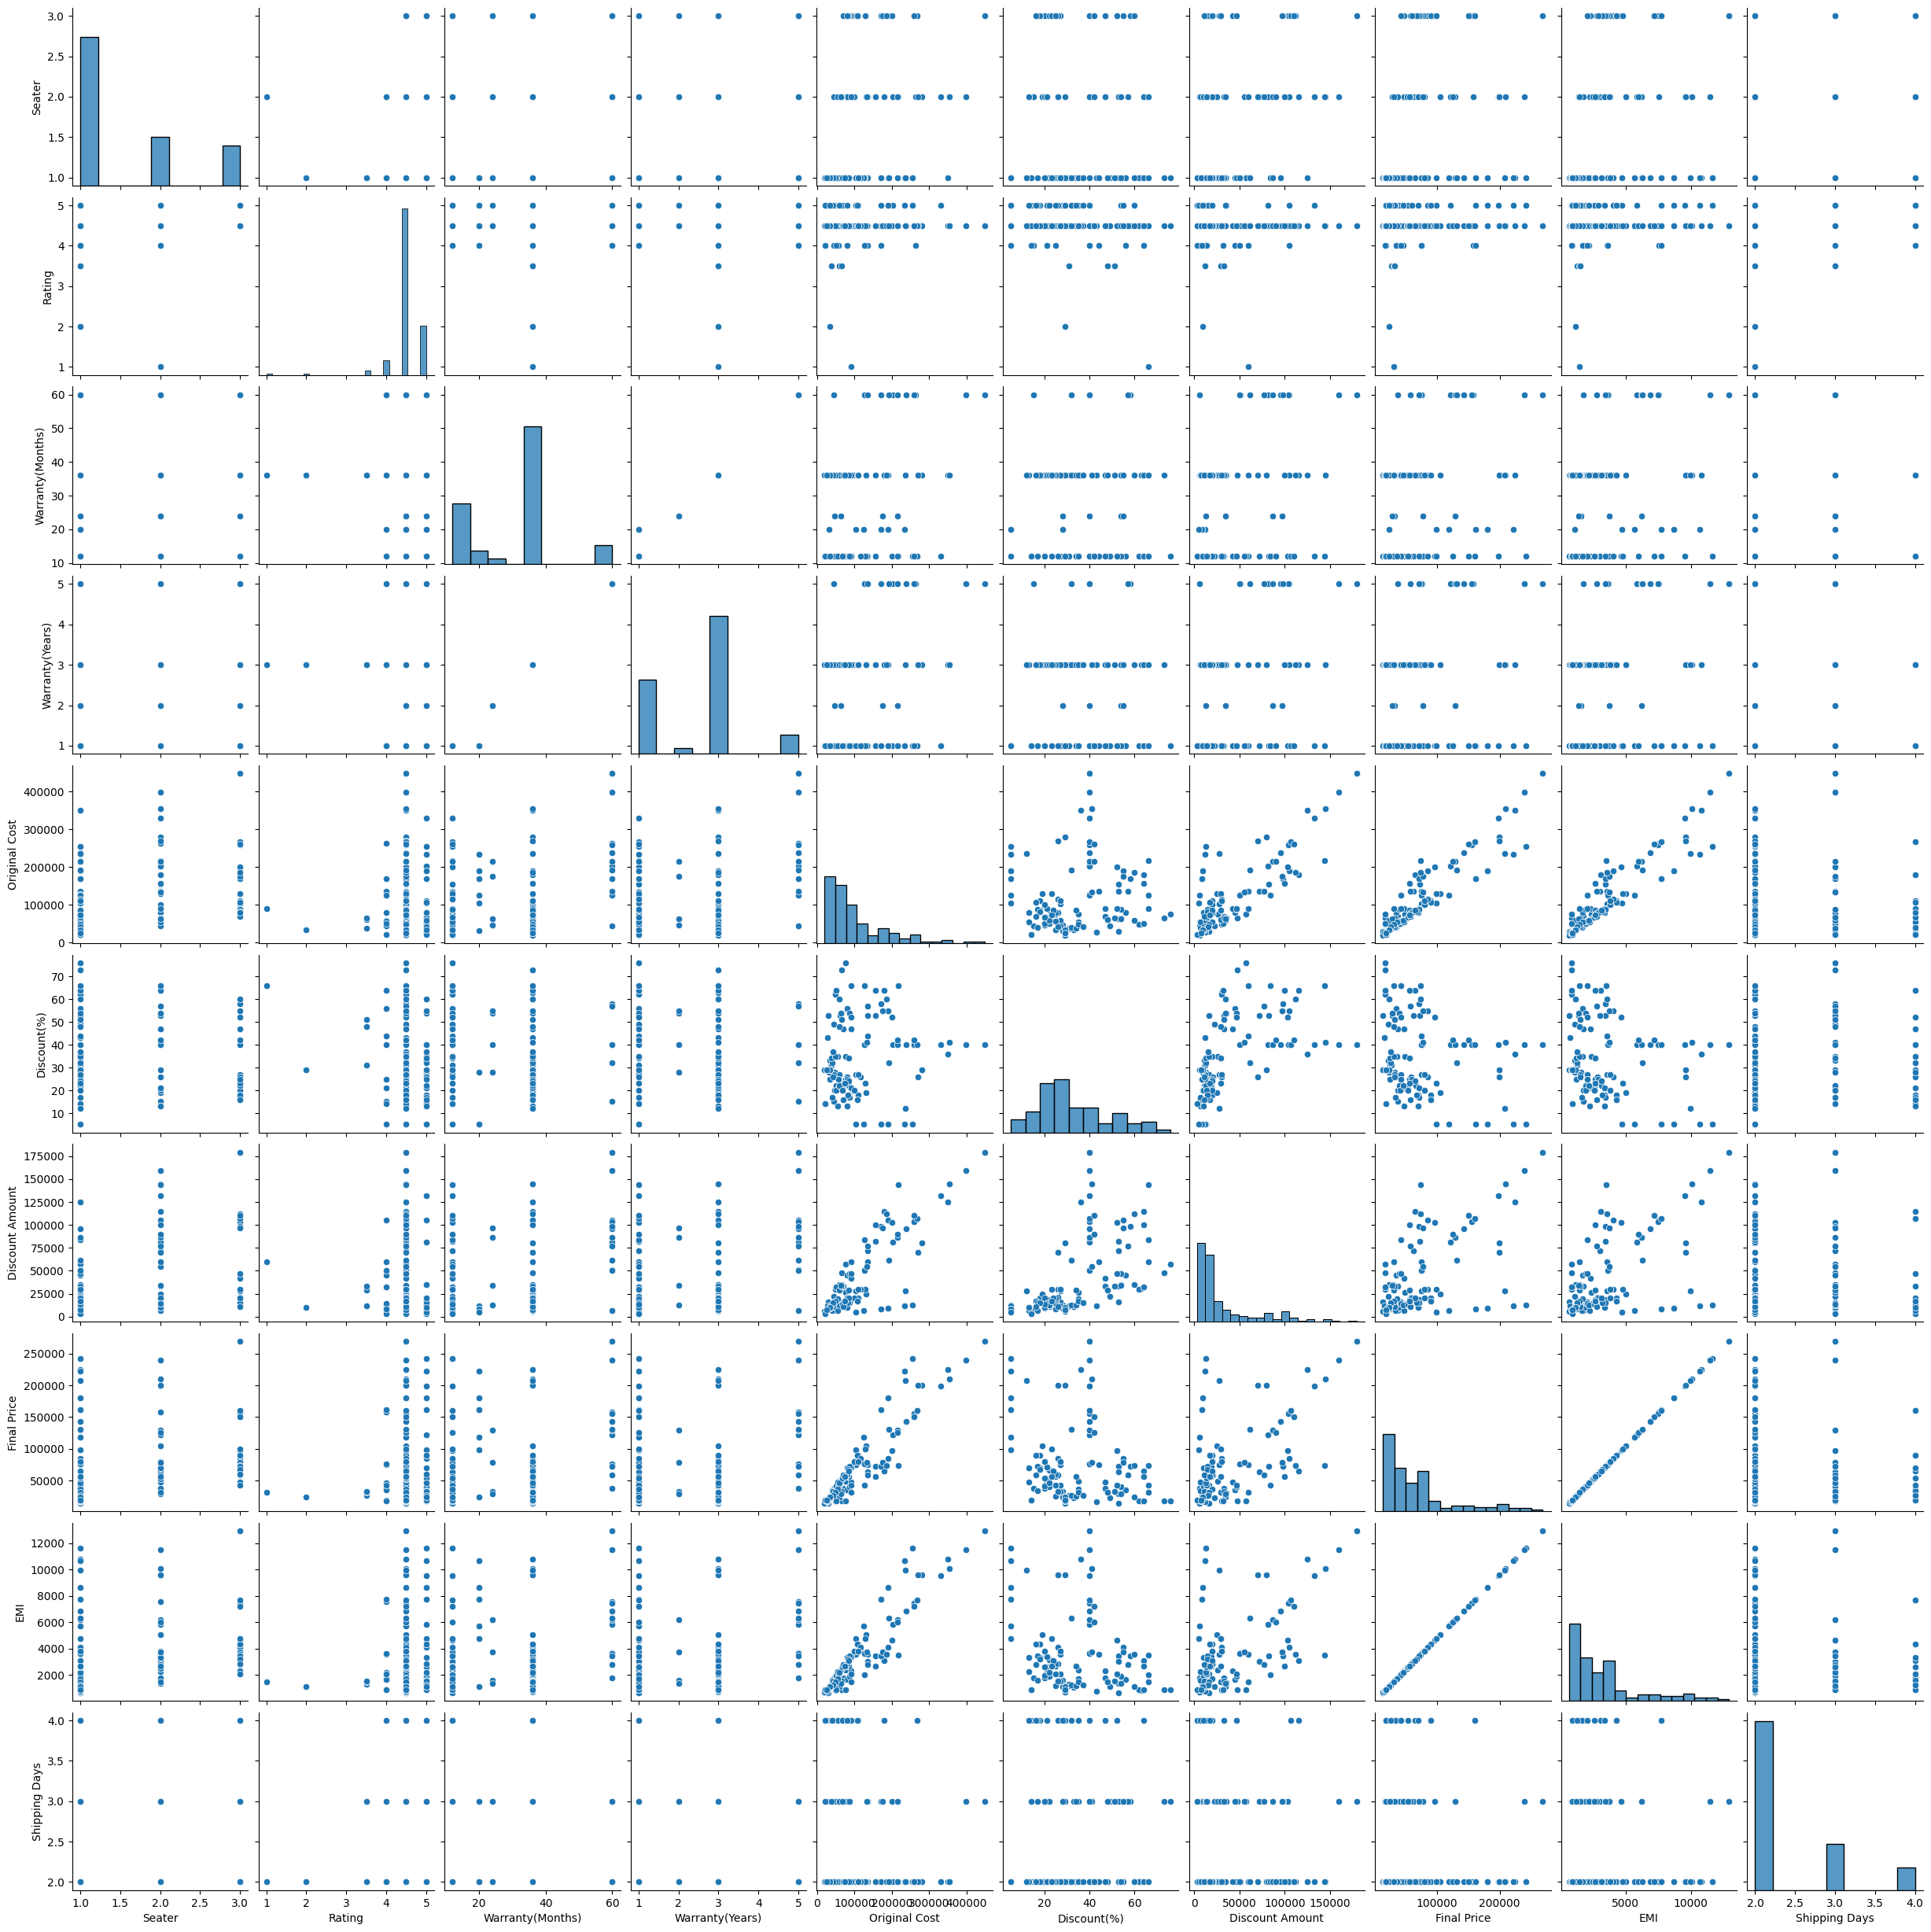

In [186]:
plt.figure(figsize=(5,5))
sns.pairplot(
    df.select_dtypes(include=[np.number])
)

plt.show()

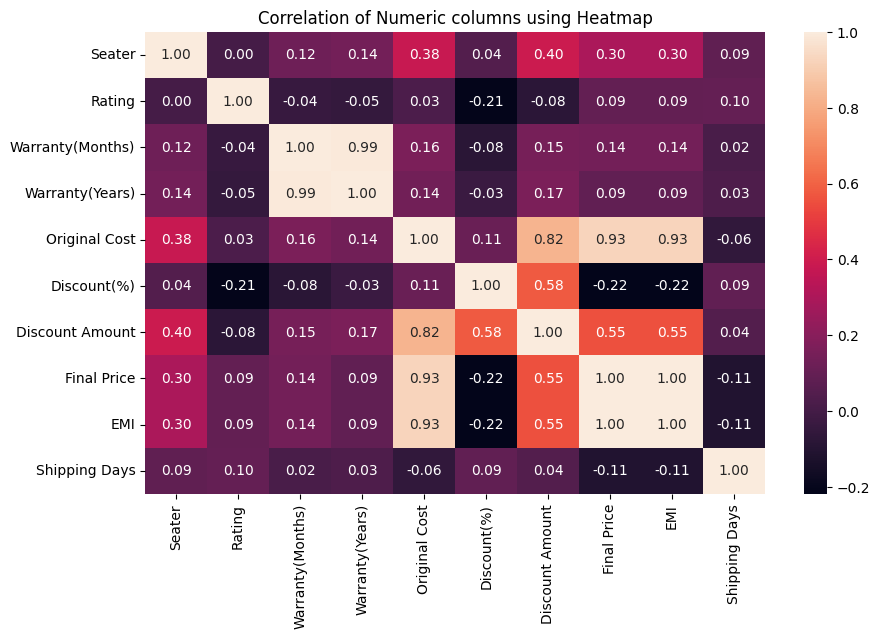

In [193]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f')
plt.title('Correlation of Numeric columns using Heatmap')
plt.show()

**Interpretation**
- Strong linear relationship exists between Final Price and EMI.
- Original Cost and Final Price also move together.
- Discount percentage does not show a perfectly linear relationship with Final Price.

# Hypothesis Testing

### Hypothesis — Brand vs Final Price

+ Do different brands sell recliners at significantly different prices?

In [140]:
# Null hypothesis - Brand has no impact on Recliner Price
# Alternate hypothesis - Brand has significant affect on Recliner Price

In [129]:
# Brand - Categorical, Price - Numerical
# Suitable Test - ANOVA (One-way)

In [138]:
confidence_level = 0.95
alpha = 1-confidence_level

groups = [
    df[df['Brand'] == b]['Final Price'] for b in df['Brand'].unique()
]

statistic, p_value = st.f_oneway(*groups)
statistic, p_value

(np.float64(14.436505598925354), np.float64(1.416655016109648e-22))

In [141]:
if p_value <= alpha:
    print('Reject Null Hypothesis')
    print('Brand has significant affect on Recliner Price')
else:
    print('Fail to reject Null Hypothesis')
    print('Brand has no impact on Recliner Price')

Reject Null Hypothesis
Brand has significant affect on Recliner Price


**Interpretation**
- Brand significantly affects recliner pricing.
- Premium brands such as Durian, Casacraft from Pepperfry and LA-Z-BOY contain higher-priced recliners.
- Some brands mainly target budget and mid-range customers.

### Hypothesis — Seater vs Final Price

+ Does seating capacity affect recliner price?

In [143]:
# Null hypothesis - Seating capacity has no impact on Recliner Price
# Alternate hypothesis - Seating capacity has significant affect on Recliner Price

In [144]:
# Seater - Assuming as Categorical, Price - Numerical
# Suitable Test - ANOVA (One-way)

In [147]:
confidence_level = 0.95
alpha = 1-confidence_level

groups = [
    df[df['Seater'] == b]['Final Price'] for b in df['Seater'].unique()
]

statistic, p_value = st.f_oneway(*groups)
statistic, p_value

(np.float64(9.762655876484601), np.float64(0.00010087283402344894))

In [148]:
if p_value <= alpha:
    print('Reject Null Hypothesis')
    print('Seating capacity has significant affect on Recliner Price')
else:
    print('Fail to reject Null Hypothesis')
    print('Seating capacity has no impact on Recliner Price')

Reject Null Hypothesis
Seating capacity has significant affect on Recliner Price


**Interpretation**
- Recliner seating capacity significantly impacts pricing.
- Multi-seater recliners generally belong to premium price categories.
- However, some 1-seater recliners are also highly priced due to luxury branding and premium features.

### Hypothesis — Discount vs Final Price

+ Is there a relationship between discount percentage and final recliner price?

In [150]:
# Null hypothesis - No relationship exists between Discount(%) and Final Price
# Alternate hypothesis - Discount percentage significantly relates to Final Price

In [151]:
# Seater - Numerical, Price - Numerical
# Suitable Test - Pearson Correlation

In [154]:
confidence_level = 0.95
alpha = 1-confidence_level

statistic, p_value = st.pearsonr(df['Seater'], df['Final Price'])
statistic, p_value

(np.float64(0.2989417227784448), np.float64(0.00012309269957684626))

In [155]:
if p_value <= alpha:
    print('Reject Null Hypothesis')
    print('Discount percentage significantly relates to Final Price')
else:
    print('Fail to reject Null Hypothesis')
    print('No relationship exists between Discount(%) and Final Price')

Reject Null Hypothesis
Discount percentage significantly relates to Final Price


**Interpretation**
- Discount percentage significantly relates to recliner pricing.
- Higher-priced recliners tend to receive larger discounts.
- Brands may use discounts as a strategy to attract buyers toward premium recliners.